In [25]:
import torch, numpy as np
from torch.distributions import multinomial
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
def use_svg_display():  #@save
    #注释#@save是一个特殊的标记，会将对应的函数、类或语句保存在d2l包中。
    #因此，以后无须重新定义就可以直接调用它们（例如，d2l.use_svg_display()）
    """使用svg格式在Jupyter中显示绘图"""
    # 设置matplotlib的后端为svg格式
    backend_inline.set_matplotlib_formats('svg')
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    # 设置图表的尺寸
    plt.rcParams['figure.figsize'] = figsize

In [26]:
fair_probs = torch.ones([6]) / 6 #tensor([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
multinomial.Multinomial(1, fair_probs).sample() #按照 fair_probs 的概率，抽 1 次

tensor([0., 0., 0., 1., 0., 0.])

In [27]:
multinomial.Multinomial(10, fair_probs).sample()#掷 10 次骰子，统计每个面出现了几次

tensor([2., 1., 2., 2., 2., 1.])

In [28]:
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000  # 相对频率作为估计值
#掷 1000 次骰子，然后计算每个面出现的相对频率

tensor([0.1650, 0.1610, 0.1640, 0.1890, 0.1720, 0.1490])

In [29]:
counts = multinomial.Multinomial(1000000, fair_probs).sample()
print('counts =', counts)
print('estimated probabilities =', counts / 1000000)

counts = tensor([166119., 166553., 166774., 166497., 167059., 166998.])
estimated probabilities = tensor([0.1661, 0.1666, 0.1668, 0.1665, 0.1671, 0.1670])


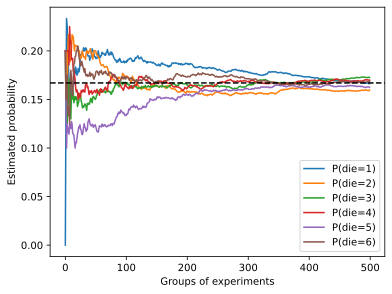

In [23]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0) # cumsum()函数返回一个张量，其元素是输入张量沿指定维度的累积和。dim=0表示沿着第0维（行）进行累积和计算。
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
set_figsize((6, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(),
             label=("P(die=" + str(i + 1) + ")"))
plt.axhline(y=0.167, color='black', linestyle='dashed')
plt.gca().set_xlabel('Groups of experiments')
plt.gca().set_ylabel('Estimated probability')
plt.legend()

这段是在画：**随着掷骰次数越来越多，每个点数的经验概率如何逐渐接近 `1/6`。**

先看这句：

```python
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
```

意思是：

```text
做 500 组实验；
每组实验掷 10 次骰子；
每组统计 6 个面分别出现了几次。
```

所以 `counts` 的形状是：

```python
counts.shape
# torch.Size([500, 6])
```

可以想象成这样：

```text
第1组10次: [2, 1, 2, 3, 1, 1]
第2组10次: [0, 2, 1, 3, 3, 1]
第3组10次: [1, 1, 2, 2, 2, 2]
...
共500行
```

每一行加起来都是 `10`。

---

然后：

```python
cum_counts = counts.cumsum(dim=0)
```

`dim=0` 是沿着“行”累加。

假设前两行是：

```text
counts[0] = [2, 1, 2, 3, 1, 1]
counts[1] = [0, 2, 1, 3, 3, 1]
```

那么：

```text
cum_counts[0] = [2, 1, 2, 3, 1, 1]
cum_counts[1] = [2, 3, 3, 6, 4, 2]
```

也就是：

```text
前10次的累计结果
前20次的累计结果
前30次的累计结果
...
前5000次的累计结果
```

所以 `cum_counts` 的形状仍然是：

```python
torch.Size([500, 6])
```

第 `i` 行表示：到目前为止，每个骰子面累计出现了多少次。

---

然后：

```python
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
```

这一步是在把“次数”变成“概率估计”。

```python
cum_counts.sum(dim=1, keepdims=True)
```

表示每一行求和。

因为每一组是 10 次，所以它大概是：

```text
[[10],
 [20],
 [30],
 ...
 [5000]]
```

注意 `keepdims=True` 让它保持二维形状：

```python
torch.Size([500, 1])
```

这样才能和：

```python
cum_counts.shape
# torch.Size([500, 6])
```

自动广播相除。

所以：

```python
estimates
```

也是：

```python
torch.Size([500, 6])
```

每一行表示：截至当前总投掷次数，6 个面的相对频率。

例如：

```text
cum_counts[1] = [2, 3, 3, 6, 4, 2]
总次数 = 20
estimates[1] = [0.10, 0.15, 0.15, 0.30, 0.20, 0.10]
```

---

最后画图：

```python
for i in range(6):
    plt.plot(estimates[:, i].numpy(),
             label=("P(die=" + str(i + 1) + ")"))
```

这里循环 `i = 0, 1, 2, 3, 4, 5`，分别画 6 条线。

```python
estimates[:, i]
```

意思是：

```text
取所有行，第 i 列
```

也就是某一个骰子面的概率估计随实验次数变化的过程。

比如：

```python
estimates[:, 0]
```

就是“骰子掷出 1 的估计概率”：

```text
第10次后的估计概率
第20次后的估计概率
第30次后的估计概率
...
第5000次后的估计概率
```

所以最终图上有 6 条曲线：

```text
P(die=1)
P(die=2)
P(die=3)
P(die=4)
P(die=5)
P(die=6)
```

刚开始波动会比较大，因为样本少；越往后，总投掷次数越多，曲线会逐渐靠近：

```python
1 / 6 ≈ 0.1667
```